In [2]:
# Import modules
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *
from hamiltonians3nu import *
from oscprob3nu import *

import numpy as np 
import matplotlib.pyplot as plt
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import scipy.integrate as integrate
from scipy.integrate import simpson, quad
from scipy.interpolate import interp1d
import copy as cp
import builtins
import itertools
import scipy.linalg as la
from scipy.linalg import expm
import cmath
import sympy as sp

In [3]:
# Gaussian fit
def gaus(data, amplitude, mean, sigma):
    return amplitude * math.e**((-0.5 * (data - mean)**2) / sigma**2)

def fluctuated_fit(gaus, bin_centers, counts):
    popt, _ = curve_fit(gaus, bin_centers, counts)
    return popt

def param_values2(param=None, sigma_fraction=0.0):
    """
    Returns oscillation parameter values at a given fraction of their uncertainty.

    Args:
        param (str): Name of the parameter.
        sigma_fraction (float): Fraction of the uncertainty (-1 to 1 for ±1σ).

    Returns:
        float: Parameter value adjusted by the given fraction of uncertainty.
    """

    params = {
        'Dm2_21': (7.53e-5, 0.0),  # No uncertainty specified
        's2th12': (0.307, 0.0),  # No uncertainty specified
        's2th13': (0.0210, 0.0011),  # ± 0.0011
        'Dm2_32': (2.41e-3, 0.07e-3),  # ± 0.07e-3
        's2th23': (0.57, 0.03, 0.04),  # +0.03, -0.04
        'd_cp': (0.82 * np.pi, 0.27 * np.pi, 0.87 * np.pi)  # +0.27π, -0.87π
    }

    if param not in params:
        raise ValueError(f"Invalid parameter: {param}")

    central = params[param][0]

    if len(params[param]) == 2:
        uncertainty = params[param][1]

        if param in ['s2th13', 's2th12']:
            return np.sqrt(central + (sigma_fraction * uncertainty))
        else:

            return central + (sigma_fraction * uncertainty)

    elif len(params[param]) == 3:
        pos_unc = params[param][1]
        neg_unc = params[param][2]

        if param in ['s2th23']:
            return np.sqrt(central + sigma_fraction * (pos_unc if sigma_fraction > 0 else neg_unc))
        else:
            return central + sigma_fraction * (pos_unc if sigma_fraction > 0 else neg_unc)

    return central
param_values2('Dm2_32', 0.5)

0.0024449999999999997

In [4]:
# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])

# Event counts for muon neutrino beam, muon-to-muon
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])
adjusted_counts_fd = np.array([ 0.  ,  7.5 ,  1.  ,  3.  ,  1.  ,  2.  ,  2.  ,  4.  ,  6.  ,
        9.  , 15.  , 12.  , 39.5 , 25.  , 19.25, 20.25, 16.  , 14.  ,
       18.  ])
adjusted_counts_nd = np.array([ 37500., 105000.,  72000.,  96000., 120000., 148000., 170000.,
       192000., 208000., 214000., 212000., 204000., 425000., 280000.,
       181500.,  81000.,  80000.,  25000.,  10000.])

# Event counts for electron neutrio beam, muon-to-electron
counts_nd_e = np.array([0.01, 0.5, 2.4, 4.6, 4, 2.6, 1.8 ,1.4, 1.2])
adjusted_counts_nd_e = np.array([10, 500, 2400, 4600, 400, 2600, 1800, 1400, 1200])
counts_fd_e = np.array([5 ,21, 18, 4, 1, 1])
bin_centers_e = np.array([0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25])
bin_edges_e = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5])

length_nd = 1 # [km]
length_fd = 810 # [km]

bin_widths = bin_edges[1:] - bin_edges[:-1]

# Event counts for antineutrino beam
anti_counts_nd = np.array([2.5, 20, 38.75, 45 ,67.5, 70, 85, 97.5, 107.5, 113.75, 115, 111.25, 95, 62.5, 37.5, 20, 10, 2.5, 0])
anti_counts_fd = np.array([0.25, 2, 1, 2, 0, 2, 3, 0, 0, 8, 3, 7, 4.4, 6, 2.4, 2, 2.4, 1.25, 1.75])
anti_counts_nd_e = np.array([0, 0.25, 1.3, 2.5, 2.52, 1.9, 1.35, 1.15, 0.95]) # The High CNN one, cause it might be better?
anti_counts_fd_e = np.array([1, 8, 5, 3, 1, 1])

adjusted_anti_counts_nd_e = np.array([0, 250, 1300, 2500, 2520, 1900, 1350, 1150, 950])
adjusted_anti_counts_nd = anti_counts_nd * (bin_widths / 0.1) * 1000
adjusted_anti_counts_fd = anti_counts_fd * (bin_widths / 0.1)

print(adjusted_anti_counts_fd)

print('sum of nd events', np.sum(adjusted_counts_nd))
print('Sum of fd events',np.sum(adjusted_counts_fd))
print('Ratio fd/nd events',np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd))

print('sum of nd e events', np.sum(adjusted_counts_nd_e))
print('sum of fd e events', np.sum(counts_fd_e))
print('Ratio fd/nd e events',np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e))


print('sum of nd data points',np.sum(counts_nd))

[ 1.875  5.     1.     2.     0.     2.     3.     0.     0.     8.
  3.     7.    11.    15.     6.6    4.5   12.     6.25  17.5  ]
sum of nd events 2861000.0
Sum of fd events 214.5
Ratio fd/nd events 7.497378538972387e-05
sum of nd e events 14910
sum of fd e events 50
Ratio fd/nd e events 0.00335345405767941
sum of nd data points 2089


Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692701207105, Mean = 1.8044188236034169, Sigma = 0.525448417032163
Fitted parameters for observed the unoscillated ND electon events: Amplitude = 4.218662147714044, Mean = 2.1341687610051183, Sigma = 0.8475810459857663
Fitted parameters for observed the unoscillated antineutrino ND events: Amplitude = 113.1060196955553, Mean = 1.8355298839724858, Sigma = 0.5285564990530245
Fitted parameters for observed the unoscillated antineutrino ND electron events: Amplitude = 2.4344413635605364, Mean = 2.356842604598921, Sigma = 0.9997075655274238


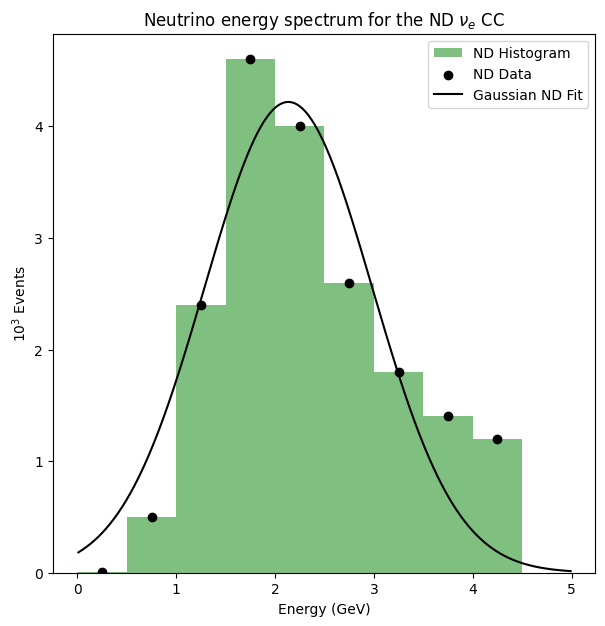

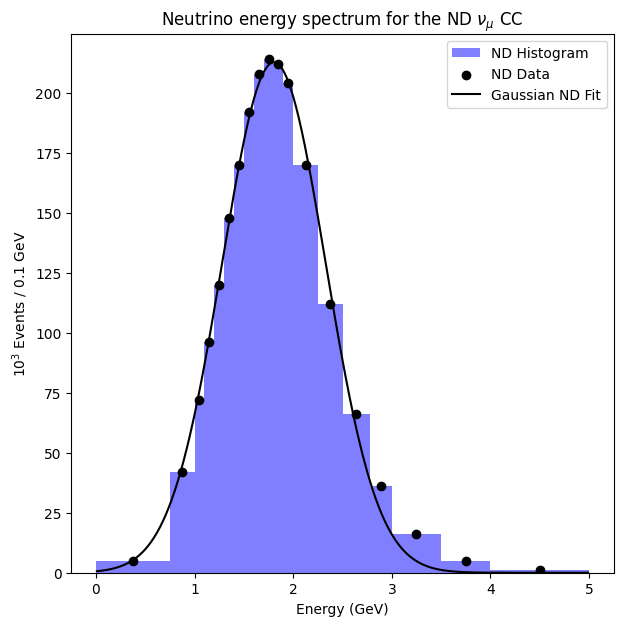

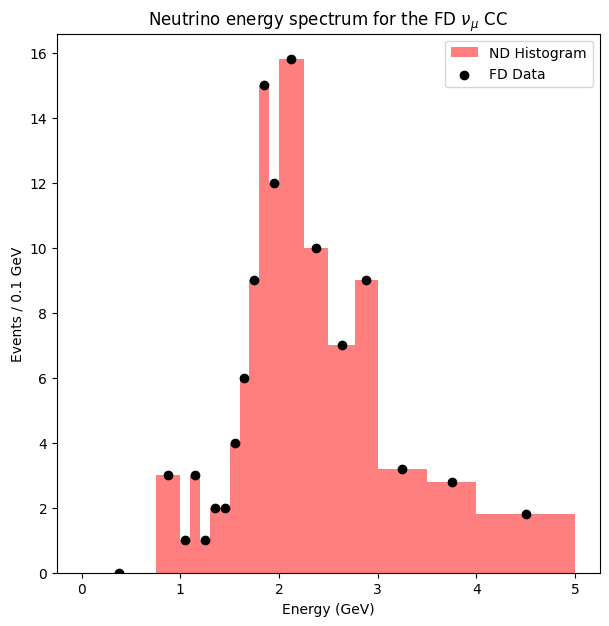

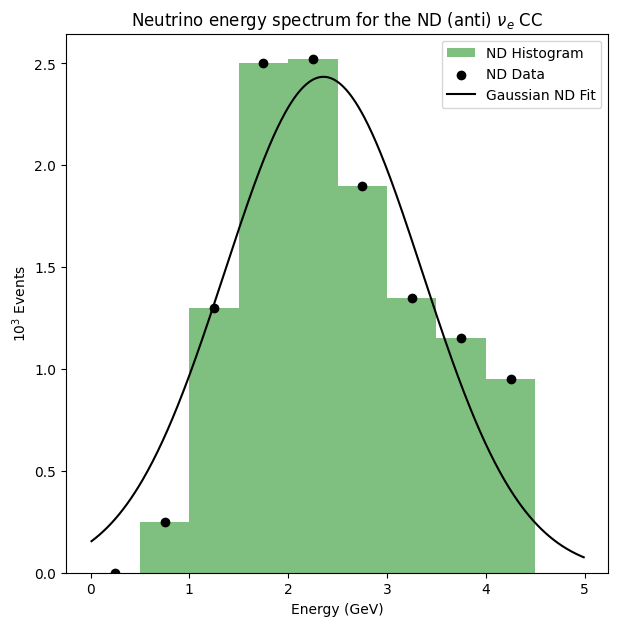

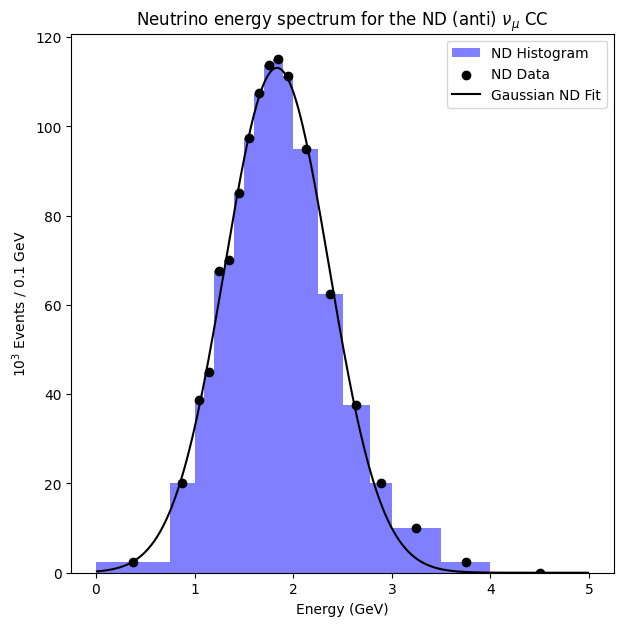

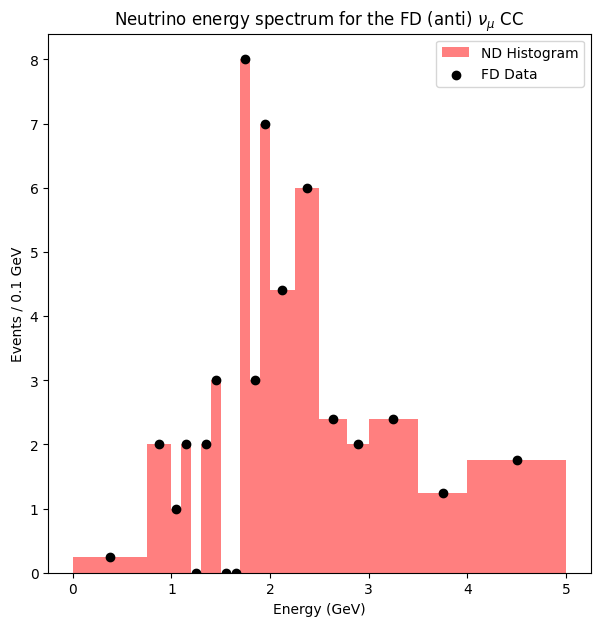

In [5]:
# Finding the Gaussian fit for the observed energy spectrum

initial_guess = [140, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess)
print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")


popt_nd_e, _ = curve_fit(gaus, bin_centers_e, counts_nd_e, p0=[5,2, 0.5])
print(f"Fitted parameters for observed the unoscillated ND electon events: Amplitude = {popt_nd_e[0]}, Mean = {popt_nd_e[1]}, Sigma = {popt_nd_e[2]}")

popt_anti_nd, _ = curve_fit(gaus, bin_centers, anti_counts_nd, p0=[120,2,0.5])
print(f"Fitted parameters for observed the unoscillated antineutrino ND events: Amplitude = {popt_anti_nd[0]}, Mean = {popt_anti_nd[1]}, Sigma = {popt_anti_nd[2]}")


popt_anti_nd_e, _ = curve_fit(gaus, bin_centers_e, anti_counts_nd_e, p0=[5,2,0.5])
print(f"Fitted parameters for observed the unoscillated antineutrino ND electron events: Amplitude = {popt_anti_nd_e[0]}, Mean = {popt_anti_nd_e[1]}, Sigma = {popt_anti_nd_e[2]}")

x = np.arange(0.01,5,0.01)


plt.figure(figsize=(7,7))
plt.hist(bin_edges_e[:-1],bin_edges_e ,weights=counts_nd_e, density=False, alpha=0.5, color='g', label='ND Histogram')
plt.scatter(bin_centers_e, counts_nd_e, color='black', label='ND Data')
plt.plot(x, gaus(x,*popt_nd_e), color='black', label='Gaussian ND Fit')
plt.title(r'Neutrino energy spectrum for the ND $\nu _e$ CC')
plt.ylabel('$10^3$ Events')
plt.xlabel('Energy (GeV)')
plt.legend()
plt.show()

plt.figure(figsize=(7,7))
plt.hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.5, color='b', label='ND Histogram')
plt.scatter(bin_centers, counts_nd, color='black', label='ND Data')
plt.plot(x, gaus(x,*popt_nd), color='black', label='Gaussian ND Fit')
plt.title(r'Neutrino energy spectrum for the ND $\nu _\mu$ CC')
plt.ylabel('$10^3$ Events / 0.1 GeV')
plt.xlabel('Energy (GeV)')
plt.legend()
plt.show()

plt.figure(figsize=(7,7))
plt.hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.5, color='r', label='ND Histogram')
plt.scatter(bin_centers, counts_fd, color='black', label='FD Data')
plt.title(r'Neutrino energy spectrum for the FD $\nu _\mu$ CC')
plt.ylabel('Events / 0.1 GeV')
plt.xlabel('Energy (GeV)')
plt.legend()
plt.show()

plt.figure(figsize=(7,7))
plt.hist(bin_edges_e[:-1],bin_edges_e ,weights=anti_counts_nd_e, density=False, alpha=0.5, color='g', label='ND Histogram')
plt.scatter(bin_centers_e, anti_counts_nd_e, color='black', label='ND Data')
plt.plot(x, gaus(x,*popt_anti_nd_e), color='black', label='Gaussian ND Fit')
plt.title(r'Neutrino energy spectrum for the ND (anti) $\nu _e$ CC')
plt.ylabel('$10^3$ Events')
plt.xlabel('Energy (GeV)')
plt.legend()
plt.show()

plt.figure(figsize=(7,7))
plt.hist(bin_edges[:-1],bin_edges ,weights=anti_counts_nd, density=False, alpha=0.5, color='b', label='ND Histogram')
plt.scatter(bin_centers, anti_counts_nd, color='black', label='ND Data')
plt.plot(x, gaus(x,*popt_anti_nd), color='black', label='Gaussian ND Fit')
plt.title(r'Neutrino energy spectrum for the ND (anti) $\nu _\mu$ CC')
plt.ylabel('$10^3$ Events / 0.1 GeV')
plt.xlabel('Energy (GeV)')
plt.legend()
plt.show()

plt.figure(figsize=(7,7))
plt.hist(bin_edges[:-1], bin_edges,weights=anti_counts_fd, density=False, alpha=0.5, color='r', label='ND Histogram')
plt.scatter(bin_centers, anti_counts_fd, color='black', label='FD Data')
plt.title(r'Neutrino energy spectrum for the FD (anti) $\nu _\mu$ CC')
plt.ylabel('Events / 0.1 GeV')
plt.xlabel('Energy (GeV)')
plt.legend()
plt.show()

In [6]:
def osc_prob_2nu(type, sector, case, length, transition):
    """
    Returns oscillated fit, event counts, Poisson fluctuated counts and probabilities

    Args:
        type (str): 'neutrino' or 'antineutrino'
        sector (str): '12' or '23'
        case (str): 'vacuum' or 'matter'
        length (int): detector distance
        transition: (str): 'mm' muon-to-muon, 'me' muon-to-electron, etc
    """
    energy = x*1e9
    length_scaled = length * CONV_KM_TO_INV_EV

    if sector == '12':
        mixing_angle = math.sqrt(0.307)
        delta_mass_squared = 7.53e-5
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = math.sqrt(0.57)
        delta_mass_squared = 2.41e-3
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")
    
    index = transition_map.get(transition)
    if index is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")
    
    if type == 'neutrino':
        if index == 2:
            popt = popt_nd_e
            bin_edge = bin_edges_e
        else:
            popt = popt_nd
            bin_edge = bin_edges
    elif type == 'antineutrino':
        if index == 2:
            popt = popt_anti_nd_e
            bin_edge = bin_edges_e
        else:
            popt = popt_anti_nd
            bin_edge = bin_edges
    else:
        raise ValueError(f"Invalid type '{type}'. Must be 'neutrino' or 'antineutrino'.")

    # Calculate energy-independent vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)

    # Define a function for Hamiltonian calculation
    if case == 'vacuum':
        def calculate_hamiltonian(e): 
            return h_vacuum_energy_indep / e
    elif case == 'matter':
        def calculate_hamiltonian(e): return hamiltonian_2nu_matter(h_vacuum_energy_indep, e, VCC_EARTH_CRUST)
    else:
        raise ValueError(f"Invalid case '{case}'. Must be 'vacuum' or 'matter'.")
    
    # Compute probabilities
    probabilities = [
        probabilities_2nu(calculate_hamiltonian(e), length_scaled)[index]
        for e in energy
    ]

    gaus_fit = probabilities * gaus(x, *popt)
    gaussian_func = interp1d(x, gaus_fit, fill_value=0, bounds_error=False)
    print('Total number of events (without scaling) = ', np.sum(gaus_fit))

    # Getting the counts
    areas = []
    for i in range(len(bin_edge) - 1):
        a, b = bin_edge[i], bin_edge[i + 1]
        area, _ = quad(gaussian_func, a, b)
        areas.append(area)

    bin_widths = np.diff(bin_edge)
    print('Areas = ', areas)
    areas = np.array(areas)
    print('Sum of areas = ', np.sum(areas))

    scaling_factors = {
        ('antineutrino', 2): (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((2.8660591490085867 / 2.1877097330051222e-05)**-1),
        ('antineutrino', None): (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * (14981.358271525794 / 2954.5295146861217)),
        ('neutrino', 2): (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((3.927803858672282 / 2.603064690020676e-05)**-1),
        ('neutrino', None): (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * 28014.98644788842 / 5558.977756872476),
        }
    
    if length == length_fd:
        factor = scaling_factors.get((type, index), scaling_factors.get((type, None), 1))
        counts = (areas / bin_widths) * factor

    elif length == length_nd:
        counts = areas / bin_widths

    print('Counts = ', counts)
    print('Total Counts = ', np.sum(counts))
    fluc_counts = np.random.poisson(counts)

    return gaus_fit, counts, fluc_counts, np.array(probabilities)
 
        

In [7]:
def osc_prob_3nu(type, case, length, transition, fractions):
    """
    Returns counts, error bars, poisson fluctuated counts, probabilities

    Args:
        type (str): 'neutrino' or 'antineutrino'
        case (str): 'vacuum' or 'matter'
        length (int): detector distance
        transition: (str): 'Pmm' muon-to-muon, 'Pme' muon-to-electron, etc
        fractions (float): Fraction of the uncertainty (-1 to 1 for ±1σ)
    """
    # Constants
    energy = x * 1e9
    length_scaled = length * CONV_KM_TO_INV_EV
    length_scaled_nd = 1 * CONV_KM_TO_INV_EV
    length_scaled_fd = 810 * CONV_KM_TO_INV_EV
    
    # Mapping of transitoin types of indices
    transition_map = {'Pee': 0, 'Pem': 1, 'Pet': 2, 'Pme': 3, 'Pmm': 4, 
                      'Pmt': 5, 'Pte': 6, 'Ptm': 7, 'Ptt': 8}
    index = transition_map.get(transition)
    if index is None:
        raise ValueError(f"Invalid transition: {transition}")
    
    # Fixed and varying parameters for calculations
    fixed_params = ['s2th12', 'Dm2_21']
    varying_params = ['s2th23', 's2th13', 'd_cp', 'Dm2_32']
    fixed_param_values = {param: param_values2(param, 0) for param in fixed_params} # Fixed parameter values obtained from a function
    fraction_combiantion = list(itertools.product(fractions, repeat=len(varying_params))) # Generating combinations of fractions for varying parameters
    
    # Getting params based on type
    if type == 'neutrino':
        if index == 3:
            popt = popt_nd_e
            bin_edge = bin_edges_e
        else:
            popt = popt_nd
            bin_edge = bin_edges
    elif type == 'antineutrino':
        if index == 3:
            popt = popt_anti_nd_e
            bin_edge = bin_edges_e
        else:
            popt = popt_anti_nd
            bin_edge = bin_edges
    else:
        raise ValueError(f"Invalid type '{type}'. Must be 'neutrino' or 'antineutrino'.")
    
    # Dictionary to store Hamiltonians and counts
    hamiltonians = {}
    counts_dict = {}
    size_dict = {}
    iterations = 0
    
    gaus_x = gaus(x, *popt)

    # Loop through each fraction combination
    for fraction_values in fraction_combiantion:
        # Obtain parameter values for varying parameters
        param_values = {param: param_values2(param, frac) for param, frac in zip(varying_params, fraction_values)}
        iterations += 1
        full_param_values = {**fixed_param_values, **param_values}
        print(f'Iteration {iterations} with params: {param_values}')

        # Calculate Hamiltonian
        hamiltonians[fraction_values] = hamiltonian_3nu_vacuum_energy_independent(
        full_param_values['s2th12'],
        full_param_values['s2th23'],
        full_param_values['s2th13'],
        full_param_values['d_cp'],
        full_param_values['Dm2_21'],
        full_param_values['Dm2_32']
    )

        # Adjust Hamiltonian based on case
        if case == 'vacuum':
            def calculate_hamiltonian(h, e): return h / e
        elif case == 'matter':
            def calculate_hamiltonian(h, e): return hamiltonian_3nu_matter(h, e, VCC_EARTH_CRUST)
        else:
            raise ValueError('Invalid case')
        
        # Oscillation probability calculation
        probabilities = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e),
                                           length_scaled)[index] for e in energy])
        osc_prob = probabilities * gaus_x
        gaussian_func = interp1d(x, osc_prob, fill_value=0, bounds_error=False)

        prob_me_nd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_nd)[3] for e in energy])
        prob_me_fd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_fd)[3] for e in energy])
        prob_mm_nd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_nd)[4] for e in energy])
        prob_mm_fd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_fd)[4] for e in energy])

        gaus_me_nd, gaus_me_fd = prob_me_nd * gaus_x, prob_me_fd * gaus_x
        gaus_mm_nd, gaus_mm_fd = prob_mm_nd * gaus_x, prob_mm_fd * gaus_x

        # Calculate areas under the curve for probability distribution
        areas = [quad(gaussian_func, bin_edge[i], bin_edge[i+1])[0] for i in range(len(bin_edge) - 1)]
        bin_widths = np.diff(bin_edge)
        areas = np.array(areas)

        # Scaling factors based on detector type and index
        scaling_factors = {
            ('antineutrino', 3): (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd))),
            ('antineutrino', None): (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * (np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))),
            ('neutrino', 3): (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd))),
            ('neutrino', None): (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd)),
        }

        # Determines counts
        if length == 810:
            factor = scaling_factors.get((type, index), scaling_factors.get((type, None), 1))
            counts = (areas / bin_widths) * factor

        elif length == 1:
            counts = areas / bin_widths
        else:
            raise ValueError('Invalid Length')
        
        # Store counts and their sum in dictionaries
        counts_dict[fraction_values] = counts
        size_dict[fraction_values] = np.sum(counts)
    
    # Find counts at zero fraction and corresponding highest and lowest counts
    zero_fraction = tuple(0 for _ in varying_params)
    if zero_fraction not in counts_dict:
        raise KeyError(f'Fraction {zero_fraction} not found in counts_dict. Check your input fractions.')
    count_at_zero = counts_dict[zero_fraction]
    highest_fraction = builtins.max(size_dict, key=size_dict.get)
    lowest_fraction = builtins.min(size_dict, key=size_dict.get)
    highest_count = size_dict[highest_fraction]
    lowest_count = size_dict[lowest_fraction]

    print(f"Highest count: {highest_count} at fraction: {highest_fraction}")
    print(f"Corresponding parameters: {[f'{param}={param_values2(param, frac)}' for param, frac in zip(varying_params, highest_fraction)]}")
    print(f"Lowest count: {lowest_count} at fraction: {lowest_fraction}")
    print(f"Corresponding parameters: {[f'{param}={param_values2(param, frac)}' for param, frac in zip(varying_params, lowest_fraction)]}")

    # Retrieve counts and errors for highest and lowest fractions
    upper_counts = counts_dict[highest_fraction]
    lower_counts = counts_dict[lowest_fraction]
    upper_error = upper_counts - count_at_zero
    lower_error = count_at_zero - lower_counts
    sys_err = np.abs([lower_error, upper_error])
    print(f'Lower error = {lower_error}, Upper_error = {upper_error}')

    # Generate Poisson fluctuated counts
    fluc_counts = np.random.poisson(count_at_zero)

    return np.array(count_at_zero), sys_err, fluc_counts, np.array(probabilities)

In [8]:
def mixing_matrix_4nu(alpha):
# Returns the mixing matrix for a given alpha
# alpha can be [np.pi / 4, np.pi / 6, np.pi / 3]

    c12 = math.sqrt(1 - param_values2('s2th12', 0)**2)
    s12 = param_values2('s2th12', 0)
    s23 = param_values2('s2th23', 0)
    c23 = math.sqrt(1 - param_values2('s2th23', 0)**2)
    s13 = param_values2('s2th13', 0)
    c13 = math.sqrt(1 - param_values2('s2th13', 0)**2)


    c_alpha = np.cos(alpha)
    s_alpha = np.sin(alpha)
    dCP = 0.82* np.pi
    cdCP = np.cos(dCP)
    sdCP = np.sin(dCP)

    # mixing matrix from https://arxiv.org/pdf/1601.05391

    A = -(c23*s12 + c12*s13*s23*complex(cdCP,sdCP))
    B = c23*c12 - s12*s13*s23*complex(cdCP,sdCP)
    C = s23*s12 - c12*s13*s23*complex(cdCP,sdCP)
    D = -(s23*c12 + s12*s13*c23*complex(cdCP,sdCP))

    U00 = c12*c13*c_alpha
    U01 = c13*(s12*c_alpha - c12*s_alpha**2)
    U02 = -c13*s_alpha**2 * (c12*c_alpha + s12) + s13*c_alpha
    U03 = c13*s_alpha*c_alpha*(c12*c_alpha + s12) +s13*s_alpha

    U10 = A*c_alpha
    U11 = -A*s_alpha**2 + B*c_alpha
    U12 = -A*s_alpha**2*c_alpha - B*s_alpha**2 + c13*s23* complex(cdCP,sdCP) *c_alpha
    U13 = A * s_alpha*c_alpha**2 + B*s_alpha*c_alpha + c13*s23 * complex(cdCP,sdCP) *s_alpha

    U20 = C*c_alpha
    U21 = -C*s_alpha**2 + D*c_alpha
    U22 = -C*s_alpha**2 * c_alpha - D*s_alpha**2 + c13*c23*complex(cdCP,sdCP)* c_alpha
    U23 = C*s_alpha*c_alpha**2 + D*s_alpha*c_alpha + c13*s23*complex(cdCP,sdCP) *s_alpha
    
    U30 = -s_alpha
    U31 = -s_alpha*c_alpha
    U32 = -s_alpha*c_alpha**2
    U33 = c_alpha**3

    return [[U00, U01, U02, U03], [U10, U11, U12, U13], [U20, U21, U22, U23], [U30, U31, U32, U33]]

def mixing_matrix_4nu_v2(osc_sterile):

    c12 = math.sqrt(1 - param_values2('s2th12', 0)**2)
    s12 = param_values2('s2th12', 0)
    s23 = param_values2('s2th23', 0)
    c23 = math.sqrt(1 - param_values2('s2th23', 0)**2)
    s13 = param_values2('s2th13', 0)
    c13 = math.sqrt(1 - param_values2('s2th13', 0)**2)

    delta13 = 0.82* np.pi
    delta14 = 0.82* np.pi
    delta34 = 0.82* np.pi

    if osc_sterile:

        th14 = 3.6 #degrees
        th24 = 4 # degrees
        th34 = 18.5 #degrees
    else:
        th14, th24, th34 = 0,0,0
        delta14, delta34 = 0,0

    c14, s14 = np.cos(np.radians(th14)), np.sin(np.radians(th14))
    c24, s24 = np.cos(np.radians(th24)), np.sin(np.radians(th24))
    c34, s34 = np.cos(np.radians(th34)), np.sin(np.radians(th34))

    # mixing matrix from https://arxiv.org/pdf/2106.15945
    U = np.array([
    [c14*c13*c12, c14*c13*s12, c14*np.exp(-1j * delta13)*s13, np.exp(-1j * delta13)*s14],

    [(-c24*c23*s12 - (c24*s23*s13*c12*np.exp(-1j * delta13) - s24*s14*c13*c12*np.exp(-1j * delta14))),    
     (c24*c23*c12 - (c24*s23*s13*s12*np.exp(1j * delta13) - s24*s14*c13*s12*np.exp(1j * delta14))),
     (-c24*s23*c13 - s24*s14*s13*np.exp(-1j * (delta13-delta14))),
     s24*c14],

    [c34*s23*s12 - c34*c23*s13*c12*np.exp(1j * delta13) + s34*s24*c23*s12*np.exp(-1j * delta34) + s34*s24*s23*s13*c12*np.exp(-1j * (delta34-delta13)) - s34*c24*s14*c13*c12*np.exp(-1j * (delta34-delta14)),
     -c34*s23*c12 - c34*c23*s13*s12*np.exp(1j * delta13) - s34*s24*c23*c12*np.exp(-1j * delta34) + s34*s24*s23*s13*s12*np.exp(-1j * (delta34-delta13)) - s34*c24*s14*c13*s12*np.exp(-1j * (delta34-delta14)),
     c34*c23*c13 - s34*s24*s23*c13*np.exp(-1j * delta34) - s34*c24*s14*s13*np.exp(-1j * (delta13-delta14+delta34)),
     s34*c24*c14*np.exp(-1j * delta34)],

    [-s34*s23*s12*np.exp(1j * delta34) + s34*c23*s13*c12*np.exp(1j * (delta34+delta13)) + c34*s24*c23*s12 + c34*s24*s23*s12*c12*np.exp(1j * delta13) - c34*c24*s14*c13*c12*np.exp(1j * delta14),
     s34*s23*c12*np.exp(1j * delta34) + s34*c23*s13*s12*np.exp(1j * (delta34+delta13)) - c34*s24*c23*c12 + c34*s24*s23*s13*s12*np.exp(1j * delta13) - c34*c24*s14*c13*s12*np.exp(1j * delta14),
     -s34*c23*c13*np.exp(1j * delta34) - c34*s24*s23*c13 - c34*c24*s14*s13*np.exp(-1j * (delta13-delta14)),
     c34*c24*c14]
    ])
    return U

def hamiltonian_4nu_v2(Dm41, osc_sterile=False):
    Dm21 = param_values2('Dm2_21', 0)
    Dm31 = param_values2('Dm2_32', 0)
    f = 1/2

    M2 = np.array([[0,0,0,0],[0,Dm21,0,0],[0,0,Dm31,0],[0,0,0,Dm41]]) # guessed mass matrix, using info for the 2x2 and 3x3 matrices
    R = np.array(mixing_matrix_4nu_v2(osc_sterile))
    #print('Mixing matrix', R)
    H = list(f*np.matmul(R, np.matmul(M2, np.conj(matrix.transpose(R)))))
    return H

def hamiltonian_4nu(alpha, Dm41):
# returns the hamltonian for a given alpha and Dm14 (delta mass squared j4, (j=1,2,3 but all Dmj4 have the same value))
# Dm14 = [0.9, 0.043] eV      
    Dm21 = param_values2('Dm2_21', 0)
    Dm31 = param_values2('Dm2_32', 0)
    f = 1/2

    M2 = np.array([[0,0,0,0],[0,Dm21,0,0],[0,0,Dm31,0],[0,0,0,Dm41]]) # guessed mass matrix, using info for the 2x2 and 3x3 matrices
    R = np.array(mixing_matrix_4nu(alpha))
    #print('Mixing matrix', R)
    H = list(f*np.matmul(R, np.matmul(M2, np.conj(matrix.transpose(R)))))

    return H

def hamiltonian_4nu_matter(hamiltonian, energy, VCC):
    H_matter = cp.deepcopy(hamiltonian)
    H_matter = np.multiply(1/energy, H_matter)
    H_matter[0][0] += VCC
    return H_matter

def evolution_operator_4nu(hamiltonian_matrix, L):
    """
    Computes the evolution operator U = exp(-i H L) for 4 neutrino flavors.
    """
    return expm(-1j * hamiltonian_matrix * L)

def probabilities_4nu(hamiltonian_matrix, L):
    """
    Computes the oscillation probabilities P(ν_α → ν_β) for a 4-flavor neutrino model.
    """
    U = evolution_operator_4nu(hamiltonian_matrix, L)

    Pee = abs(U[0, 0])**2
    Pem = abs(U[1, 0])**2
    Pet = abs(U[2, 0])**2
    Pes = abs(U[3, 0])**2

    Pme = abs(U[0, 1])**2
    Pmm = abs(U[1, 1])**2
    Pmt = abs(U[2, 1])**2
    Pms = abs(U[3, 1])**2

    Pte = abs(U[0, 2])**2
    Ptm = abs(U[1, 2])**2
    Ptt = abs(U[2, 2])**2
    Pts = abs(U[3, 2])**2

    Pse = abs(U[0, 3])**2
    Psm = abs(U[1, 3])**2
    Pst = abs(U[2, 3])**2
    Pss = abs(U[3, 3])**2

    return {
        "Pee": Pee, "Pem": Pem, "Pet": Pet, "Pes": Pes,
        "Pme": Pme, "Pmm": Pmm, "Pmt": Pmt, "Pms": Pms,
        "Pte": Pte, "Ptm": Ptm, "Ptt": Ptt, "Pts": Pts,
        "Pse": Pse, "Psm": Psm, "Pst": Pst, "Pss": Pss
    }


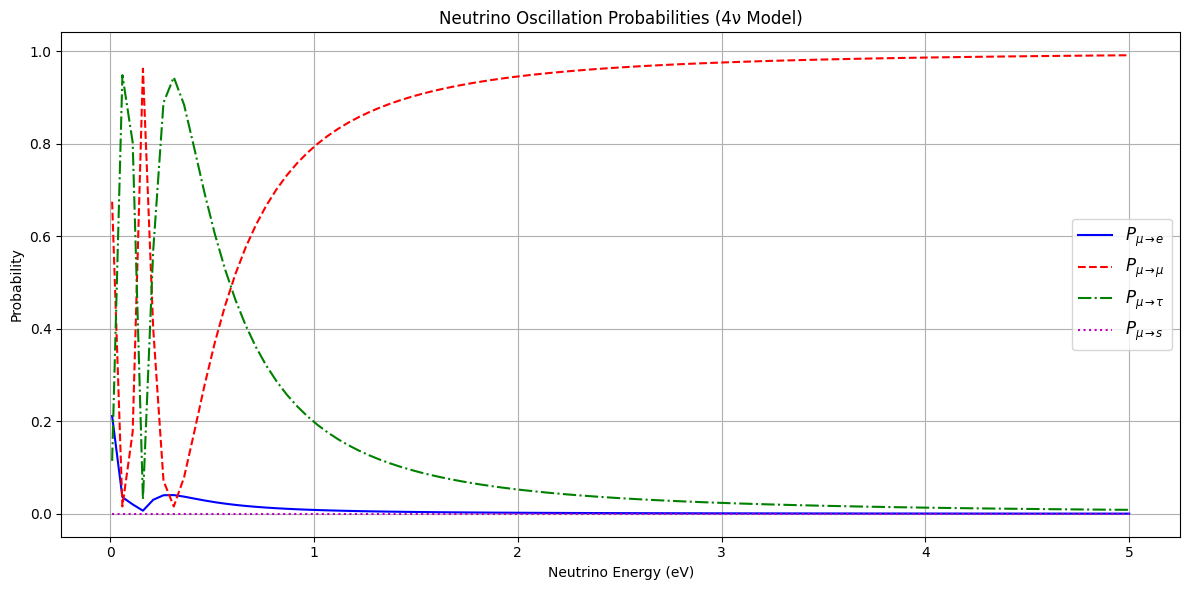

In [9]:
x1 = np.linspace(0.01, 5, 100)

h = hamiltonian_4nu(0, 0.0)
def calculate_hamiltonian_vac(h, e): return h / e

def calculate_hamiltonian_mat(h, e): return hamiltonian_4nu_matter(h, e, VCC_EARTH_CRUST)
prob_results = [probabilities_4nu(calculate_hamiltonian_vac(h, e), 810) for e in x1]

# Extract probabilities of interest
Pme = [prob['Pme'] for prob in prob_results]
Pmm = [prob['Pmm'] for prob in prob_results]
Pmt = [prob['Pmt'] for prob in prob_results]
Pms = [prob['Pms'] for prob in prob_results]

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x1, Pme, label=r'$P_{\mu \,\to\,e}$', linestyle='-', color='b')
plt.plot(x1, Pmm, label=r'$P_{\mu \,\to\,\mu}$', linestyle='--', color='r')
plt.plot(x1, Pmt, label=r'$P_{\mu \,\to\,\tau}$', linestyle='-.', color='g')
plt.plot(x1, Pms, label=r'$P_{\mu \,\to\,s}$', linestyle=':', color='m')

# Labels and legends
plt.xlabel('Neutrino Energy (eV)')
plt.ylabel('Probability')
plt.title('Neutrino Oscillation Probabilities (4ν Model)')
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
# Show the plot
plt.show()

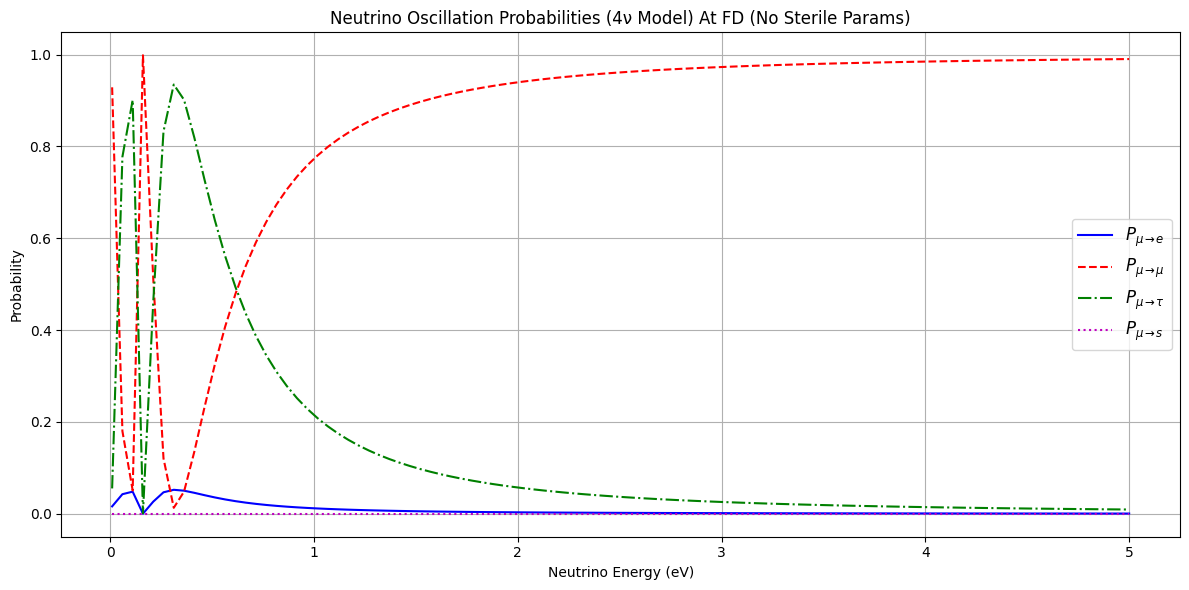

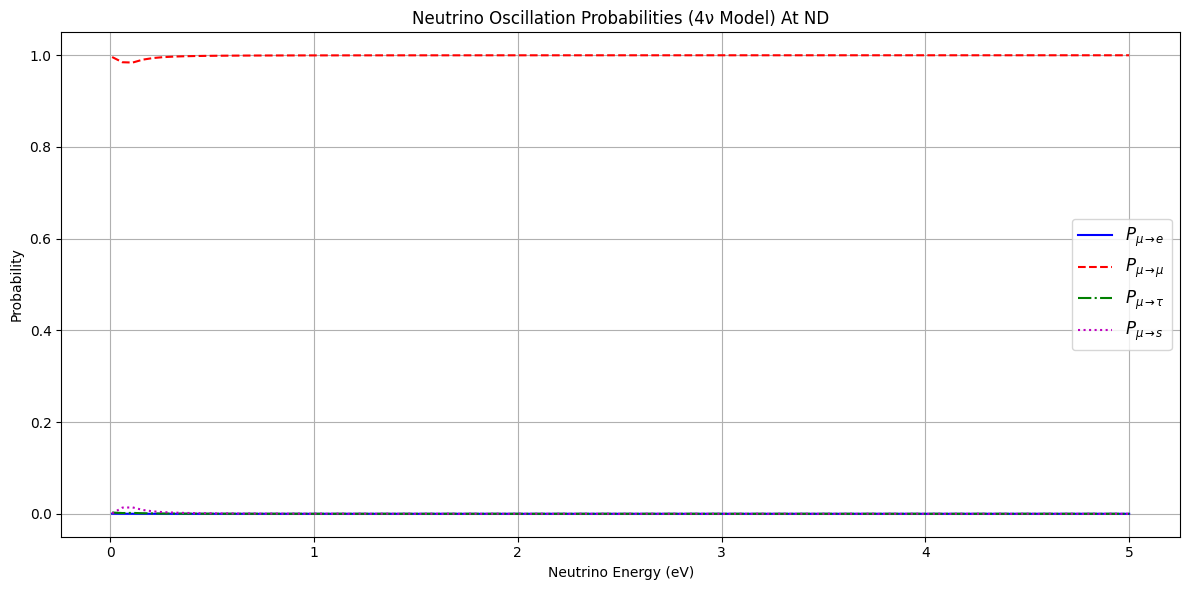

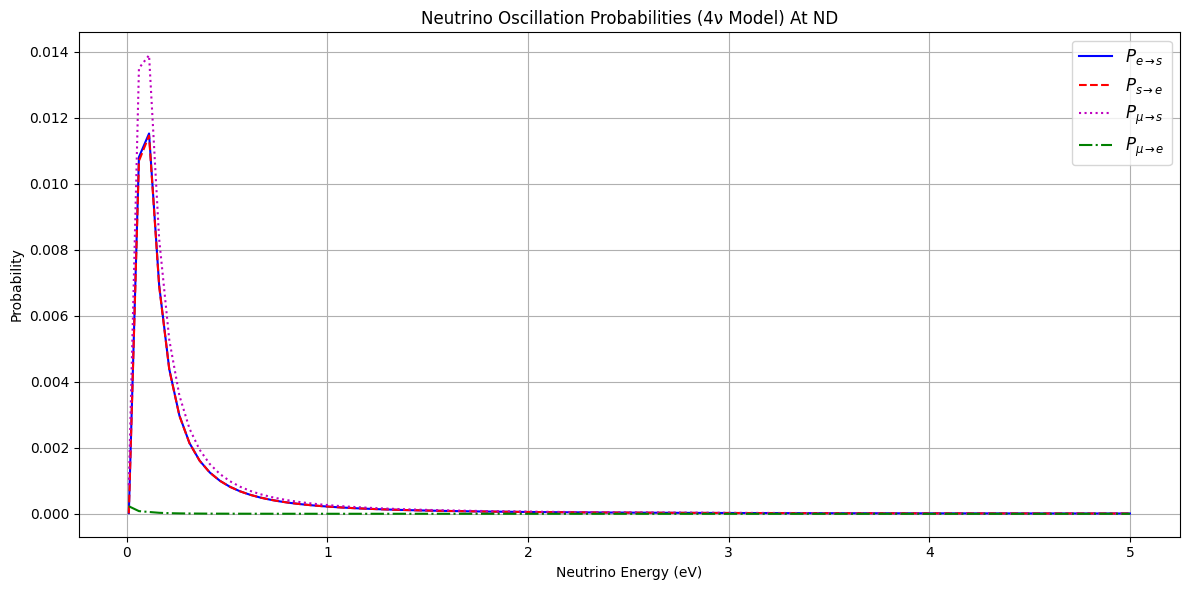

In [10]:
h2 = hamiltonian_4nu_v2(0)
prob_results2 = [probabilities_4nu(calculate_hamiltonian_vac(h2, e), 810) for e in x1]
h3 = hamiltonian_4nu_v2(0.5, osc_sterile=True)
prob_results3 = [probabilities_4nu(calculate_hamiltonian_vac(h3, e), 1) for e in x1]

# Extract probabilities of interest
Pme2 = [prob['Pme'] for prob in prob_results2]
Pmm2 = [prob['Pmm'] for prob in prob_results2]
Pmt2 = [prob['Pmt'] for prob in prob_results2]
Pms2 = [prob['Pms'] for prob in prob_results2]

Pme3 = [prob['Pme'] for prob in prob_results3]
Pmm3 = [prob['Pmm'] for prob in prob_results3]
Pmt3 = [prob['Pmt'] for prob in prob_results3]
Pms3 = [prob['Pms'] for prob in prob_results3]
Pes3 = [prob['Pes'] for prob in prob_results3]
Pse3 = [prob['Pse'] for prob in prob_results3]

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x1, Pme2, label=r'$P_{\mu \,\to\,e}$', linestyle='-', color='b')
plt.plot(x1, Pmm2, label=r'$P_{\mu \,\to\,\mu}$', linestyle='--', color='r')
plt.plot(x1, Pmt2, label=r'$P_{\mu \,\to\,\tau}$', linestyle='-.', color='g')
plt.plot(x1, Pms2, label=r'$P_{\mu \,\to\,s}$', linestyle=':', color='m')

# Labels and legends
plt.xlabel('Neutrino Energy (eV)')
plt.ylabel('Probability')
plt.title('Neutrino Oscillation Probabilities (4ν Model) At FD (No Sterile Params)')
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
# Show the plot
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(x1, Pme3, label=r'$P_{\mu \,\to\,e}$', linestyle='-', color='b')
plt.plot(x1, Pmm3, label=r'$P_{\mu \,\to\,\mu}$', linestyle='--', color='r')
plt.plot(x1, Pmt3, label=r'$P_{\mu \,\to\,\tau}$', linestyle='-.', color='g')
plt.plot(x1, Pms3, label=r'$P_{\mu \,\to\,s}$', linestyle=':', color='m')

# Labels and legends
plt.xlabel('Neutrino Energy (eV)')
plt.ylabel('Probability')
plt.title('Neutrino Oscillation Probabilities (4ν Model) At ND')
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
# Show the plot
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(x1, Pes3, label=r'$P_{e \,\to\,s}$', linestyle='-', color='b')
plt.plot(x1, Pse3, label=r'$P_{s \,\to\,e}$', linestyle='--', color='r')
plt.plot(x1, Pms3, label=r'$P_{\mu \,\to\,s}$', linestyle=':', color='m')
plt.plot(x1, Pme3, label=r'$P_{\mu \,\to\,e}$', linestyle='-.', color='g')
# Labels and legends
plt.xlabel('Neutrino Energy (eV)')
plt.ylabel('Probability')
plt.title('Neutrino Oscillation Probabilities (4ν Model) At ND')
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
# Show the plot
plt.show()

In [11]:
print('\n Model 1:')
fit1, c1, fc1, p1 = osc_prob_2nu('neutrino', '12', 'vacuum', length_nd, 'mm')
print('\n Model 2:')
fit2, c2, fc2, p2 = osc_prob_2nu('neutrino', '23', 'vacuum', length_fd, 'mm')

print('\n Model 3:')
fit3, c3, fc3, p3 = osc_prob_2nu('neutrino', '12', 'matter', length_nd, 'mm')
print('\n Model 4:')
fit4, c4, fc4, p4 = osc_prob_2nu('neutrino', '23', 'matter', length_fd, 'mm')

print('\n Model 5:')
fit1_, c1_, fc1_, p1_ = osc_prob_2nu('antineutrino', '12', 'vacuum', length_nd, 'mm')
print('\n Model 6:')
fit2_, c2_, fc2_, p2_ = osc_prob_2nu('antineutrino', '23', 'vacuum', length_fd, 'mm')

print('\n Model 7:')
fit3_, c3_, fc3_, p3_ = osc_prob_2nu('antineutrino', '12', 'matter', length_nd, 'mm')
print('\n Model 8:')
fit4_, c4_, fc4_, p4_ = osc_prob_2nu('antineutrino', '23', 'matter', length_fd, 'mm')

print('\n Model 9:')
fit5, c5, fc5, p5 = osc_prob_2nu('neutrino', '12', 'vacuum', length_nd, 'me')
print('\n Model 10:')
fit6, c6, fc6, p6 = osc_prob_2nu('neutrino', '12', 'vacuum', length_fd, 'me')

print('\n Model 11:')
fit7, c7, fc7, p7 = osc_prob_2nu('neutrino', '12', 'matter', length_nd, 'me')
print('\n Model 12:')
fit8, c8, fc8, p8 = osc_prob_2nu('neutrino', '12', 'matter', length_fd, 'me')

print('\n Model 13:')
fit5_, c5_, fc5_, p5_ = osc_prob_2nu('antineutrino', '12', 'vacuum', length_nd, 'me')
print('\n Model 14:')
fit6_, c6_, fc6_, p6_ = osc_prob_2nu('antineutrino', '12', 'vacuum', length_fd, 'me')

print('\n Model 15:')
fit7_, c7_, fc7_, p7_ = osc_prob_2nu('antineutrino', '12', 'matter', length_nd, 'me')
print('\n Model 16:')
fit8_, c8_, fc8_, p8_ = osc_prob_2nu('antineutrino', '12', 'matter', length_fd, 'me')






 Model 1:
Total number of events (without scaling) =  28014.986436829386
Areas =  [6.186176573793727, 11.35140377930323, 7.602939463607213, 9.804944194235437, 12.196271918825635, 14.632802381564526, 16.93348622895338, 18.900955709521604, 20.348840439445745, 21.130709272348437, 21.164451193256046, 20.44647644714301, 43.897298239354434, 29.545828517892794, 16.933791668620792, 5.863227353071288, 3.0317480140771322, 0.17127464154841168, 0.004113860709023662]
Sum of areas =  280.14673989727186
Counts =  [8.24823543e+00 4.54056151e+01 7.60293946e+01 9.80494419e+01
 1.21962719e+02 1.46328024e+02 1.69334862e+02 1.89009557e+02
 2.03488404e+02 2.11307093e+02 2.11644512e+02 2.04464764e+02
 1.75589193e+02 1.18183314e+02 6.15774242e+01 2.60587882e+01
 6.06349603e+00 3.42549283e-01 4.11386071e-03]
Total Counts =  2073.0915017242996

 Model 2:
Total number of events (without scaling) =  5512.9779435690025


C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\884329689.py:73: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  area, _ = quad(gaussian_func, a, b)
C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\884329689.py:73: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  area, _ = quad(gaussian_func, a, b)


Areas =  [3.473466756211676, 9.57717471148283, 3.844940556514305, 3.0677686738069507, 2.122537852307227, 1.2553673266834853, 0.6480932765902867, 0.39827998391826613, 0.5155286166439698, 0.9334254473106994, 1.5340423492562882, 2.1791694772310253, 7.504709720137508, 7.84028530554163, 6.028533226868787, 2.5519248193116457, 1.5458577087723089, 0.10452841626092593, 0.0028217934910325137]
Sum of areas =  55.12845601834084
Counts =  [1.74987410e+00 1.44744583e+01 1.45276226e+01 1.15911767e+01
 8.01974137e+00 4.74324700e+00 2.44873865e+00 1.50485065e+00
 1.94785981e+00 3.52683024e+00 5.79618539e+00 8.23371682e+00
 1.13422394e+01 1.18494114e+01 8.28292796e+00 4.28538926e+00
 1.16816565e+00 7.89894855e-02 1.06617905e-03]
Total Counts =  115.57249098180095

 Model 3:
Total number of events (without scaling) =  28014.986436829433
Areas =  [6.1861765737939995, 11.351403779303238, 7.602939463607217, 9.80494419423544, 12.196271918825635, 14.632802381564526, 16.933486228953402, 18.900955709521604, 20.

In [12]:
#fractions = np.linspace(-1,1,3) # -1*sigma, 0*sigma, 1*sigma
fractions = [0]

c_3f_1, err_3f_1, fc_3f_1, p_3f_1 = osc_prob_3nu('neutrino', 'vacuum', length_nd, 'Pem', fractions)
c_3f_2, err_3f_2, fc_3f_2, p_3f_2 = osc_prob_3nu('neutrino', 'vacuum', length_fd, 'Pem', fractions)

c_3f_3, err_3f_3, fc_3f_3, p_3f_3 = osc_prob_3nu('neutrino', 'matter', length_nd, 'Pem', fractions)
c_3f_4, err_3f_4, fc_3f_4, p_3f_4 = osc_prob_3nu('neutrino', 'matter', length_fd, 'Pem', fractions)


Iteration 1 with params: {'s2th23': 0.7549834435270749, 's2th13': 0.14491376746189438, 'd_cp': 2.57610597594363, 'Dm2_32': 0.00241}
Highest count: 0.00036411271442963246 at fraction: (0, 0, 0, 0)
Corresponding parameters: ['s2th23=0.7549834435270749', 's2th13=0.14491376746189438', 'd_cp=2.57610597594363', 'Dm2_32=0.00241']
Lowest count: 0.00036411271442963246 at fraction: (0, 0, 0, 0)
Corresponding parameters: ['s2th23=0.7549834435270749', 's2th13=0.14491376746189438', 'd_cp=2.57610597594363', 'Dm2_32=0.00241']
Lower error = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], Upper_error = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Iteration 1 with params: {'s2th23': 0.7549834435270749, 's2th13': 0.14491376746189438, 'd_cp': 2.57610597594363, 'Dm2_32': 0.00241}


C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\1750984757.py:98: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas = [quad(gaussian_func, bin_edge[i], bin_edge[i+1])[0] for i in range(len(bin_edge) - 1)]
C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\1750984757.py:98: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas = [quad(gaussian_func, bin_edge[i], bin_edge[i+1])[0] for i in range(len(bin_edge) - 1)]


Highest count: 37.46656578139542 at fraction: (0, 0, 0, 0)
Corresponding parameters: ['s2th23=0.7549834435270749', 's2th13=0.14491376746189438', 'd_cp=2.57610597594363', 'Dm2_32=0.00241']
Lowest count: 37.46656578139542 at fraction: (0, 0, 0, 0)
Corresponding parameters: ['s2th23=0.7549834435270749', 's2th13=0.14491376746189438', 'd_cp=2.57610597594363', 'Dm2_32=0.00241']
Lower error = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], Upper_error = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Iteration 1 with params: {'s2th23': 0.7549834435270749, 's2th13': 0.14491376746189438, 'd_cp': 2.57610597594363, 'Dm2_32': 0.00241}
Highest count: 0.0003641141917154584 at fraction: (0, 0, 0, 0)
Corresponding parameters: ['s2th23=0.7549834435270749', 's2th13=0.14491376746189438', 'd_cp=2.57610597594363', 'Dm2_32=0.00241']
Lowest count: 0.0003641141917154584 at fraction: (0, 0, 0, 0)
Corresponding parameters: ['s2th23=0.7549834435270749', 's2th13=0.14491376746189438', 'd_cp=

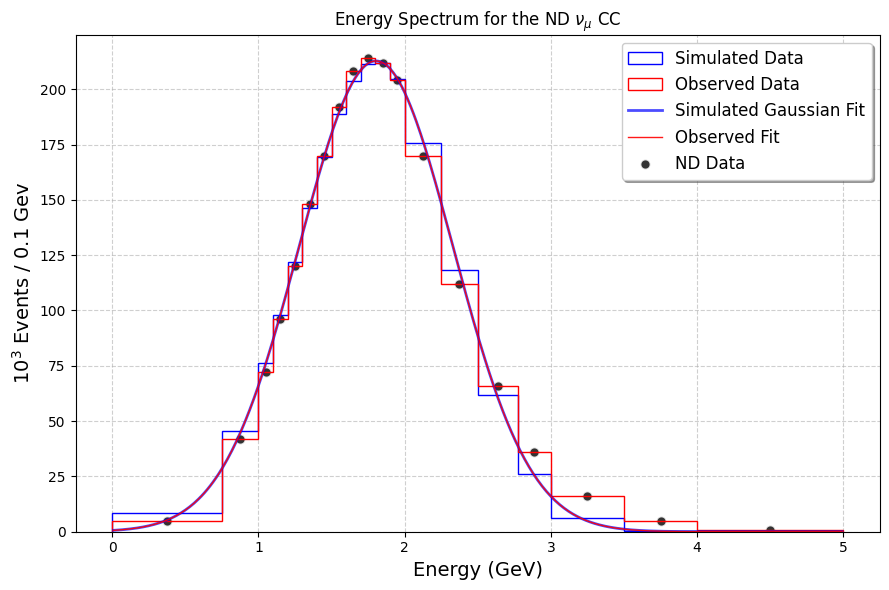

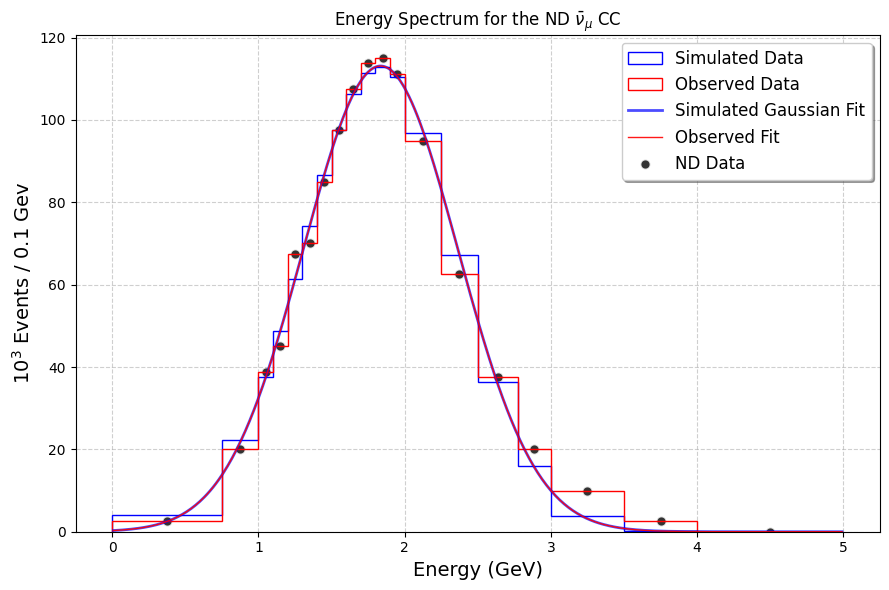

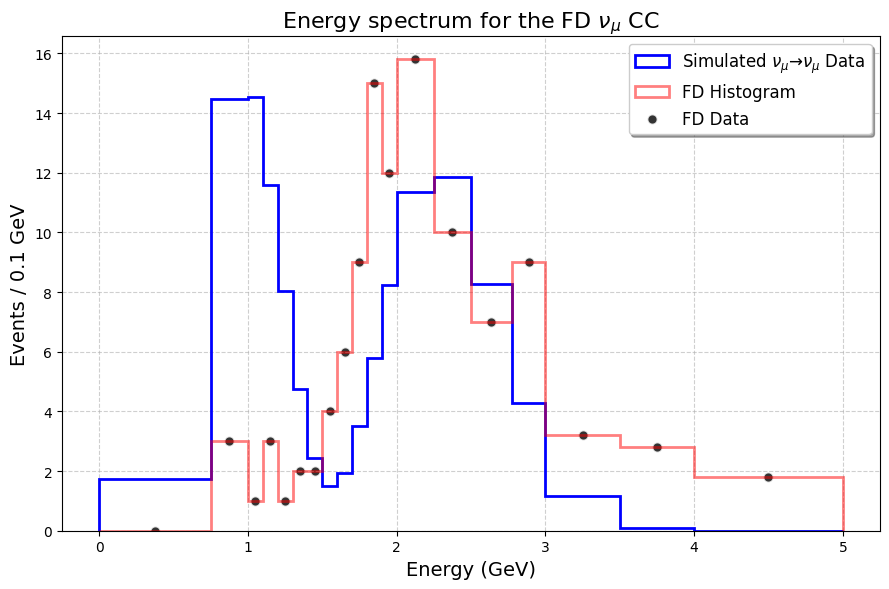

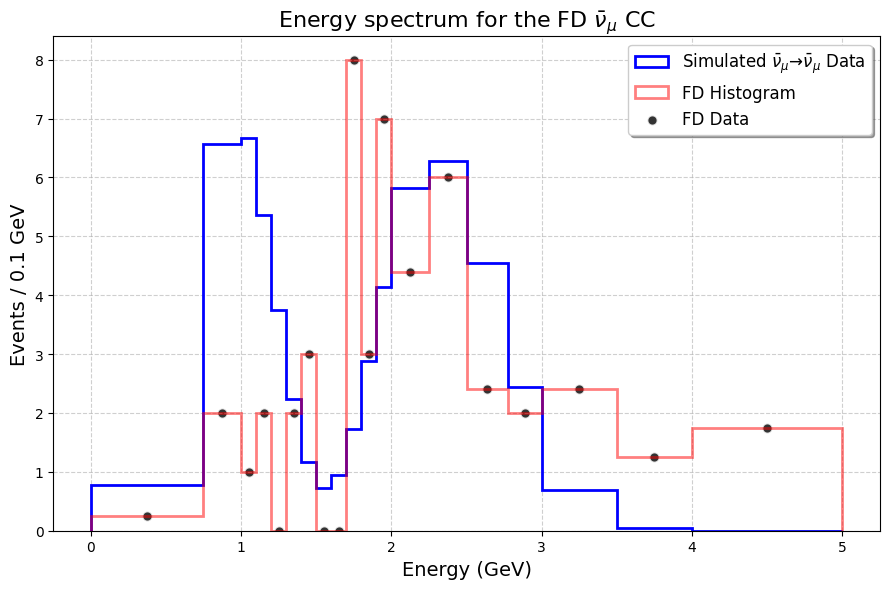

In [13]:
plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c1, histtype='step', label='Simulated Data', linewidth=1, color='blue')
plt.hist(bin_edges[:-1], bin_edges, weights=counts_nd, histtype='step', label='Observed Data', linewidth=1, color='red')
plt.plot(x,fit1, label='Simulated Gaussian Fit', linewidth=2, color='b', alpha=0.7)
plt.plot(x, gaus(x, *popt_nd), label='Observed Fit', linewidth=1, color='r', alpha=0.9)
plt.scatter(bin_centers, counts_nd, color='black', label='ND Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy Spectrum for the ND $\nu _\mu$ CC')
plt.ylabel(r'$10^3$ Events / 0.1 Gev', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c1_, histtype='step', label='Simulated Data', linewidth=1, color='blue')
plt.hist(bin_edges[:-1], bin_edges, weights=anti_counts_nd, histtype='step', label='Observed Data', linewidth=1, color='red')
plt.plot(x,fit1_, label='Simulated Gaussian Fit', linewidth=2, color='b', alpha=0.7)
plt.plot(x, gaus(x, *popt_anti_nd), label='Observed Fit', linewidth=1, color='r', alpha=0.9)
plt.scatter(bin_centers, anti_counts_nd, color='black', label='ND Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy Spectrum for the ND $\bar{\nu} _\mu$ CC')
plt.ylabel(r'$10^3$ Events / 0.1 Gev', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c2, histtype='step', label=r'Simulated $\nu _\mu \to \nu _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\nu _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c2_, histtype='step', label=r'Simulated $\bar{\nu} _\mu \to \bar{\nu} _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=anti_counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, anti_counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\bar{\nu} _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

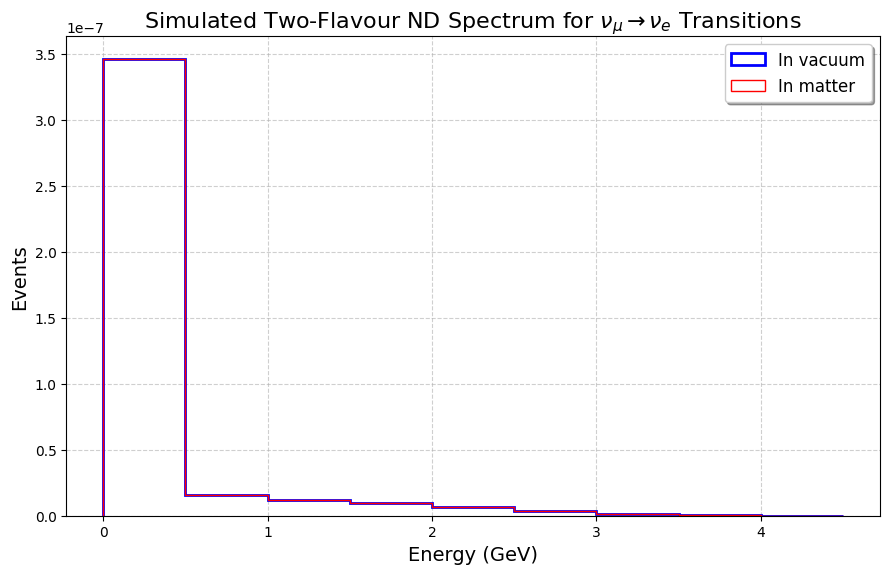

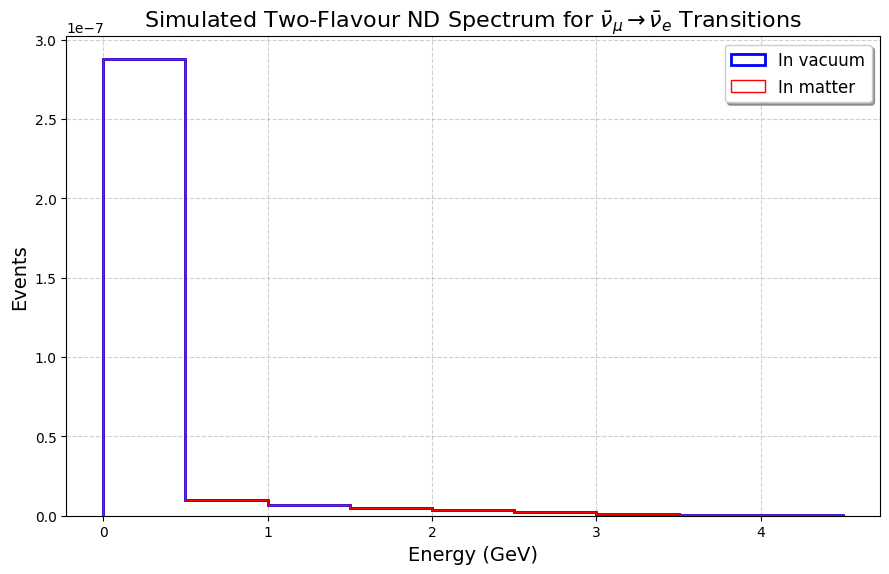

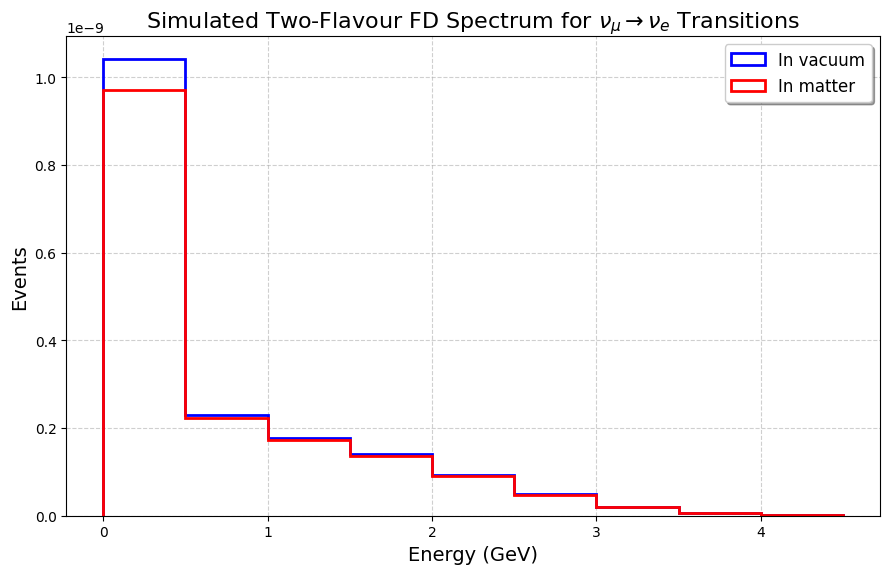

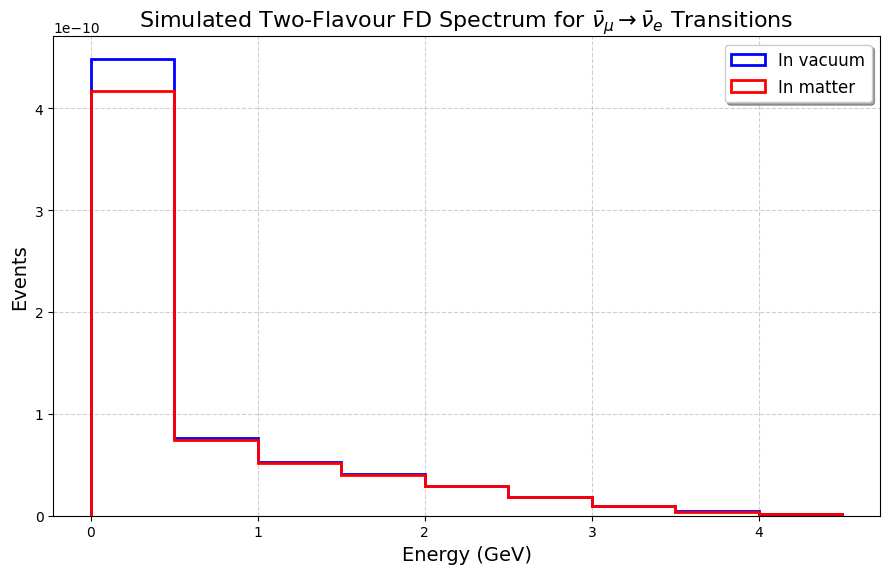

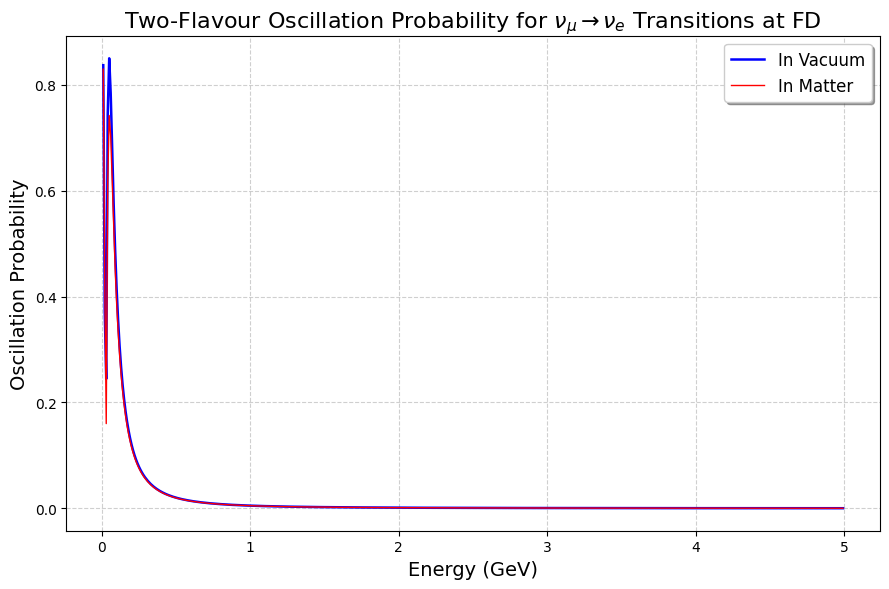

In [14]:
plt.figure(figsize=(9,6))
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c5, histtype='step', label=r'In vacuum', linewidth=2, color='blue')
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c7, histtype='step', label=r'In matter', linewidth=1, color='red')
title = r'Simulated Two-Flavour ND Spectrum for $\nu _\mu \,\to\, \nu _e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c5_, histtype='step', label=r'In vacuum', linewidth=2, color='blue')
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c7_, histtype='step', label=r'In matter', linewidth=1, color='red')
title = r'Simulated Two-Flavour ND Spectrum for $\bar{\nu} _\mu \,\to\, \bar{\nu} _e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,6))
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c6, histtype='step', label=r'In vacuum', linewidth=2, color='blue')
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c8, histtype='step', label=r'In matter', linewidth=2, color='red')
title = r'Simulated Two-Flavour FD Spectrum for $\nu _\mu \,\to\, \nu _e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c6_, histtype='step', label=r'In vacuum', linewidth=2, color='blue')
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=c8_, histtype='step', label=r'In matter', linewidth=2, color='red')
title = r'Simulated Two-Flavour FD Spectrum for $\bar{\nu} _\mu \,\to\, \bar{\nu} _e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
plt.plot(x, p6, label=r'In Vacuum', linewidth=1.8, color='b')
plt.plot(x, p8, label=r'In Matter', linewidth=1, color='r')
title = r'Two-Flavour Oscillation Probability for $\nu _\mu\, \to\, \nu _e$ Transitions at FD'
plt.title(title, fontsize=16)
plt.ylabel('Oscillation Probability', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Total number of events (without scaling) =  36.93852628896732


C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\3024054594.py:17: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  area, _ = quad(gaussian_func, a, b)


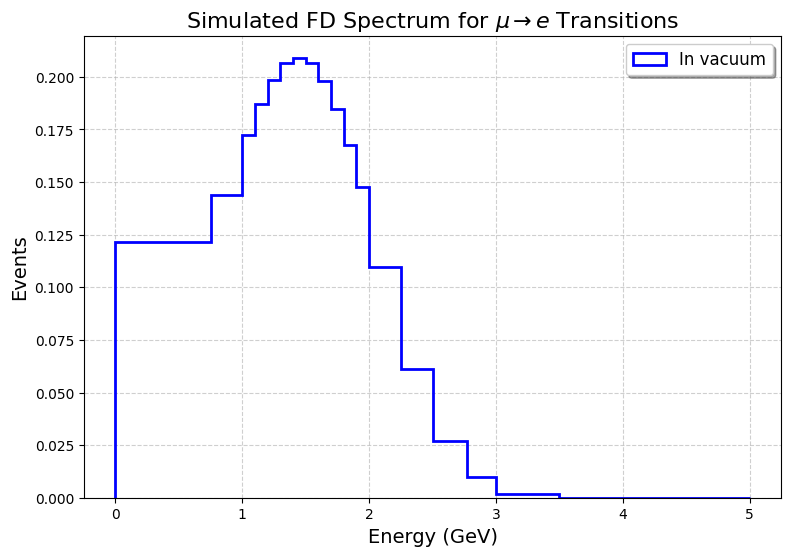

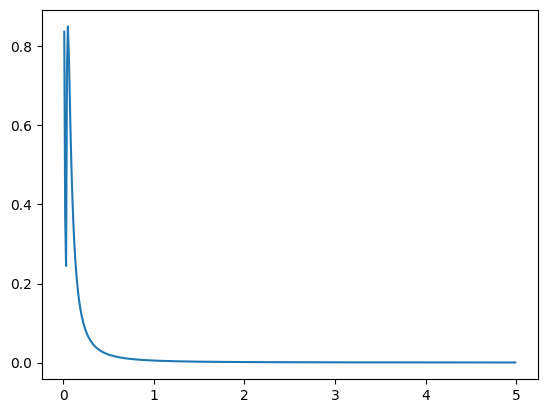

In [15]:
h_vacuum_energy_indep = hamiltonian_2nu_vacuum_energy_independent(math.sqrt(0.307), 7.53e-5)
def calculate_hamiltonian(e): 
    return h_vacuum_energy_indep / e
energy = x * 1e9        
probabilities = [
        probabilities_2nu(calculate_hamiltonian(e), length_fd*CONV_KM_TO_INV_EV)[2]
        for e in energy
    ]

gaus_fit = probabilities * gaus(x, *popt_anti_nd)
gaussian_func = interp1d(x, gaus_fit, fill_value=0, bounds_error=False)
print('Total number of events (without scaling) = ', np.sum(gaus_fit))

areas = []
for i in range(len(bin_edges) - 1):
    a, b = bin_edges[i], bin_edges[i + 1]
    area, _ = quad(gaussian_func, a, b)
    areas.append(area)
bin_widths = np.diff(bin_edges)
counts = areas / bin_widths

plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=counts, histtype='step', label=r'In vacuum', linewidth=2, color='blue')
title = r'Simulated FD Spectrum for $\mu \, \to \, e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure()
plt.plot(x, probabilities)

Total number of events (without scaling) =  12026.828847140345


C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\884329689.py:73: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  area, _ = quad(gaussian_func, a, b)


Areas =  [1.2928284873911646, 0.8692518738678569, 1.8568049361133037, 3.3555515244453122, 5.060103158778499, 6.779835672853538, 8.331277213947052, 9.55877063680238, 10.351485354792805, 10.654310710838914, 10.470590955435844, 9.8562112854193, 20.0402070256169, 12.339123790489824, 6.424706387564707, 2.0269061986721737, 0.9518641244139336, 0.04655590681409533, 0.0009926433946891538]
Sum of areas =  120.26737788765229
Counts =  [6.06217380e-01 1.22279699e+00 6.53002758e+00 1.18008325e+01
 1.77954143e+01 2.38433844e+01 2.92995074e+01 3.36163668e+01
 3.64041928e+01 3.74691716e+01 3.68230644e+01 3.46624087e+01
 2.81910290e+01 1.73577347e+01 8.21616826e+00 3.16810718e+00
 6.69504789e-01 3.27456427e-02 3.49093683e-04]
Total Counts =  327.7090235123449


C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\884329689.py:73: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  area, _ = quad(gaussian_func, a, b)


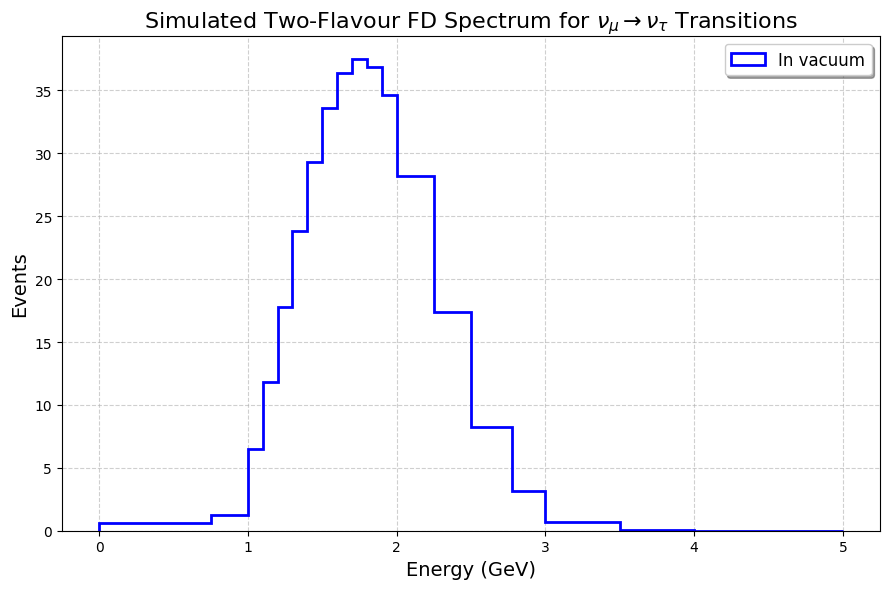

In [16]:
fit2_, c2_, fc2_, p2_ = osc_prob_2nu('antineutrino', '23', 'vacuum', length_fd, 'mt')

plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c2_, histtype='step', label=r'In vacuum', linewidth=2, color='blue')
title = r'Simulated Two-Flavour FD Spectrum for $\nu _\mu \,\to\, \nu _\tau$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [20]:
def osc_prob_2nu_fd2(mixing_angle_23, delta_mass_squared_23):

    mixing_angle_12 = math.sqrt(0.307)
    delta_mass_squared_12 = 7.53e-5

    energy = x*1e9
    length_scaled_nd = length_nd * CONV_KM_TO_INV_EV
    length_scaled_fd = length_fd * CONV_KM_TO_INV_EV

    cases = ['vacuum', 'matter']
    types = ['neutrino', 'antineutrino']
    sectors = {'12': (mixing_angle_12, delta_mass_squared_12, {'me': 2, 'mm': 3}),
               '23': (mixing_angle_23, delta_mass_squared_23, {'mm': 0, 'mt': 1})}
    
    all_counts = {}

    for case in cases:
        for particle_type in types:
            h_mm_nd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_12, delta_mass_squared_12)
            h_me_nd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_12, delta_mass_squared_12)
            h_me_fd = h_me_nd

            h_mm_fd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_23, delta_mass_squared_23)
            h_mt_fd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_23, delta_mass_squared_23)

            if case == 'vacuum':
                def calculate_hamiltonian(h, e):
                    return h / e
            elif case == 'matter':
                def calculate_hamiltonian(h,e):
                    return hamiltonian_2nu_matter(h, e, VCC_EARTH_CRUST)
                
            prob_mm_nd = [probabilities_2nu(calculate_hamiltonian(h_mm_nd, e), length_scaled_nd)[3]
                        for e in energy]
            prob_ee_nd = [probabilities_2nu(calculate_hamiltonian(h_mm_nd, e), length_scaled_nd)[0]
                        for e in energy]
            prob_me_nd = [probabilities_2nu(calculate_hamiltonian(h_me_nd, e), length_scaled_nd)[2]
                        for e in energy]
            prob_me_fd = [probabilities_2nu(calculate_hamiltonian(h_me_fd, e), length_scaled_fd)[2]
                        for e in energy]
            
            prob_mm_fd = [probabilities_2nu(calculate_hamiltonian(h_mm_fd, e), length_scaled_fd)[0]
                        for e in energy]
            prob_mt_fd = [probabilities_2nu(calculate_hamiltonian(h_mt_fd, e), length_scaled_nd)[1]
                        for e in energy]
            
            if particle_type == 'neutrino':
                    popt2 = popt_nd_e
                    bin_edge2 = bin_edges_e
                    popt1 = popt_nd
                    bin_edge1 = bin_edges
            elif particle_type == 'antineutrino':
                    popt1 = popt_anti_nd_e
                    bin_edge2 = bin_edges_e
                    popt2 = popt_anti_nd
                    bin_edge1 = bin_edges

            osc_prob_mm_nd = prob_mm_nd * gaus(x, *popt1)
            gf_mm_nd = interp1d(x, osc_prob_mm_nd, fill_value=0, bounds_error=False)

            osc_prob_ee_nd = prob_ee_nd * gaus(x, *popt2)
            gf_ee_nd = interp1d(x, osc_prob_ee_nd, fill_value=0, bounds_error=False)
            
            osc_prob_me_nd = prob_me_nd * gaus(x, *popt2)
            gf_me_nd = interp1d(x, osc_prob_me_nd, fill_value=0, bounds_error=False)

            osc_prob_me_fd = prob_me_fd * gaus(x, *popt2)
            gf_me_fd = interp1d(x, osc_prob_me_fd, fill_value=0, bounds_error=False)

            osc_prob_mm_fd = prob_mm_fd * gaus(x, *popt1)
            gf_mm_fd = interp1d(x, osc_prob_mm_fd, fill_value=0, bounds_error=False)

            osc_prob_mt_fd = prob_mt_fd * gaus(x, *popt1)
            gf_mt_fd = interp1d(x, osc_prob_mt_fd, fill_value=0, bounds_error=False)

            areas1 = []
            areas2 = []
            areas3 = []
            areas4 = []
            areas5 = []
            areas6 = []

            for i in range(len(bin_edge1) - 1):
                a, b = bin_edge1[i], bin_edge1[i + 1]
                area1, _ = quad(gf_mm_nd, a, b)
                areas1.append(area1)

                area2, _ = quad(gf_mm_fd, a, b)
                areas2.append(area2)

                area3, _ = quad(gf_mt_fd, a, b)
                areas3.append(area3)

            for i in range(len(bin_edge2) - 1):
                a, b = bin_edge2[i], bin_edge2[i + 1]
                area4, _ = quad(gf_me_nd, a, b)
                areas4.append(area4)

                area5, _ = quad(gf_me_fd, a, b)
                areas5.append(area5)

                area6, _ = quad(gf_ee_nd, a, b)
                areas6.append(area6)

            bin_widths1 = np.diff(bin_edge1)
            bin_widths2 = np.diff(bin_edge2)

            if particle_type == 'neutrino':
                counts1 = (areas1 / bin_widths1)
                counts2 = (areas2 / bin_widths1) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))
                counts3 = (areas3 / bin_widths1) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))

                counts4 = (areas4 / bin_widths2)
                counts5 = (areas4 / bin_widths2) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(osc_prob_me_nd) / np.sum(osc_prob_me_fd)))
                counts6 = (areas6 / bin_widths2)
                
            elif particle_type == 'antineutrino':
                counts1 = (areas1 / bin_widths1)
                counts2 = (areas2 / bin_widths1) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))
                counts3 = (areas3 / bin_widths1) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))

                counts4 = (areas4 / bin_widths2)
                counts5 = (areas4 / bin_widths2) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(osc_prob_me_nd) / np.sum(osc_prob_me_fd)))
                counts6 = (areas6 / bin_widths2)

            all_counts[(particle_type, case)] = (counts1, counts2, counts3, counts4, counts5, counts6)

    return all_counts

mixing_angle_23 = np.sqrt(0.57)
delta_mass_squared_32 = 2.41e-3
results2 = osc_prob_2nu_fd2(mixing_angle_23, delta_mass_squared_32)
counts_mm_nd, counts_mm_fd, counts_mt_fd, counts_me_nd, counts_me_fd, counts_ee_nd = results2[('neutrino', 'vacuum')]
counts_mm_nd_anti, counts_mm_fd_anti, counts_mt_fd_anti, counts_me_nd_anti, counts_me_fd_anti, counts_ee_nd_anti = results2[('antineutrino', 'matter')]

C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\2654535571.py:85: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  area1, _ = quad(gf_mm_nd, a, b)
C:\Users\Raees\AppData\Local\Temp\ipykernel_3680\2654535571.py:88: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the inte

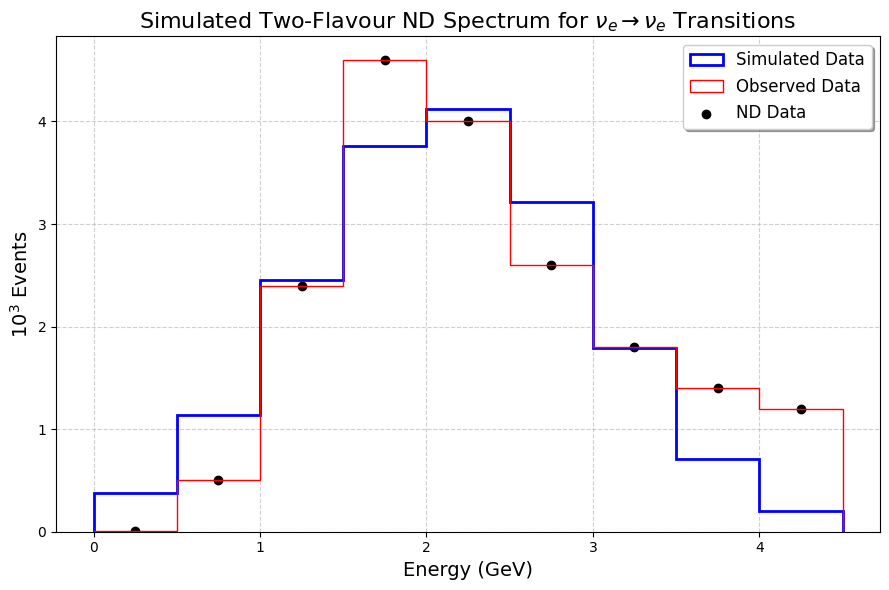

In [28]:
plt.figure(figsize=(9,6))
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=counts_ee_nd, histtype='step', label=r'Simulated Data', linewidth=2, color='blue')
plt.hist(bin_edges_e[:-1], bin_edges_e, weights=counts_nd_e, histtype='step', label=r'Observed Data', linewidth=1, color='red')
plt.scatter(bin_centers_e, counts_nd_e, color='black', label='ND Data')
title = r'Simulated Two-Flavour ND Spectrum for $\nu _e \,\to\, \nu _e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel(r'$10^3$ Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()